# **Data Preparation**

In [4]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.5 MB/s eta 0:00:00


In [27]:
# IMPORT LIBRARY
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

from sklearn.model_selection import train_test_split

from ultralytics import YOLO

import kagglehub

In [26]:
# DOWNLOAD DATASET
path = kagglehub.dataset_download("andrewmvd/car-plate-detection")
print("Dataset Path :", path)

# TENTUKAN FOLDER DATASET
image_dir = os.path.join(path, "images")
annotation_dir = os.path.join(path, "annotations")
print("Image Folder      :", image_dir)
print("Annotation Folder :", annotation_dir)

# MEMBACA XML DAN MEMBUAT DATAFRAME
data = []
xml_files = sorted(os.listdir(annotation_dir))

for xml_file in xml_files:
    xml_path = os.path.join(annotation_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(image_dir, filename)

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    obj = root.find("object")

    xmin = int(obj.find("bndbox/xmin").text)
    ymin = int(obj.find("bndbox/ymin").text)
    xmax = int(obj.find("bndbox/xmax").text)
    ymax = int(obj.find("bndbox/ymax").text)

    data.append([
        filename,
        image_path,
        width,
        height,
        xmin,
        ymin,
        xmax,
        ymax
    ])

df = pd.DataFrame(data, columns=[
    "filename",
    "image_path",
    "width",
    "height",
    "xmin",
    "ymin",
    "xmax",
    "ymax"
])

df.head()

Dataset Path : /kaggle/input/datasets/andrewmvd/car-plate-detection
Image Folder      : /kaggle/input/datasets/andrewmvd/car-plate-detection/images
Annotation Folder : /kaggle/input/datasets/andrewmvd/car-plate-detection/annotations


,filename,image_path,width,height,xmin,ymin,xmax,ymax
0,Cars0.png,/kaggle/input/datasets/andrewmvd/car-plate-det...,500,268,226,125,419,173
1,Cars1.png,/kaggle/input/datasets/andrewmvd/car-plate-det...,400,248,134,128,262,160
2,Cars10.png,/kaggle/input/datasets/andrewmvd/car-plate-det...,400,225,140,5,303,148
3,Cars100.png,/kaggle/input/datasets/andrewmvd/car-plate-det...,400,267,175,114,214,131
4,Cars101.png,/kaggle/input/datasets/andrewmvd/car-plate-det...,400,300,167,202,240,220


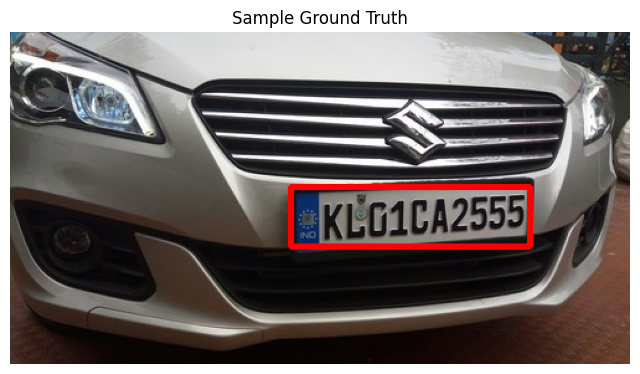

In [68]:
# VISUALISASI SAMPLE DATASET
sample = df.iloc[0]

img = cv2.imread(sample["image_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

xmin = sample["xmin"]
ymin = sample["ymin"]
xmax = sample["xmax"]
ymax = sample["ymax"]

cv2.rectangle(
    img,
    (xmin, ymin),
    (xmax, ymax),
    (255, 0, 0),
    3
)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.title("Sample Ground Truth")
plt.axis("off")
plt.show()

# **Data Preprocessing**

In [7]:
# MEMBUAT STRUKTUR DATASET YOLO
os.makedirs("dataset_yolo/images/train", exist_ok=True)
os.makedirs("dataset_yolo/images/val", exist_ok=True)
os.makedirs("dataset_yolo/labels/train", exist_ok=True)
os.makedirs("dataset_yolo/labels/val", exist_ok=True)

# SPLIT DATASET
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)
print("Train Data :", len(train_df))
print("Val Data   :", len(val_df))

Train Data : 346
Val Data   : 87


In [8]:
# FUNCTION CONVERT XML KE YOLO FORMAT
def convert_to_yolo(row, save_dir):
    image_filename = row["filename"]
    width = row["width"]
    height = row["height"]

    xmin = row["xmin"]
    ymin = row["ymin"]
    xmax = row["xmax"]
    ymax = row["ymax"]

    # YOLO FORMAT
    x_center = ((xmin + xmax) / 2) / width
    y_center = ((ymin + ymax) / 2) / height

    bbox_width = (xmax - xmin) / width
    bbox_height = (ymax - ymin) / height

    txt_filename = image_filename.replace(".png", ".txt")
    txt_path = os.path.join(save_dir, txt_filename)

    with open(txt_path, "w") as f:
        f.write(
            f"0 {x_center} {y_center} {bbox_width} {bbox_height}"
        )

# COPY TRAIN DATA
for index, row in train_df.iterrows():
    src_image = row["image_path"]
    dst_image = os.path.join(
        "dataset_yolo/images/train",
        row["filename"]
    )
    shutil.copy(src_image, dst_image)
    convert_to_yolo(
        row,
        "dataset_yolo/labels/train"
    )

In [9]:
# COPY VALIDATION DATA
for index, row in val_df.iterrows():
    src_image = row["image_path"]
    dst_image = os.path.join(
        "dataset_yolo/images/val",
        row["filename"]
    )
    shutil.copy(src_image, dst_image)
    convert_to_yolo(
        row,
        "dataset_yolo/labels/val"
    )

# MEMBUAT data.yaml
data_yaml = {
    "path": os.path.abspath("dataset_yolo"),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "license_plate"
    }
}

with open("dataset_yolo/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)
print("data.yaml berhasil dibuat")

# LOAD MODEL YOLOv8
model = YOLO("yolov8n.pt")

data.yaml berhasil dibuat


In [10]:
# TRAINING MODEL
model.train(
    data="dataset_yolo/data.yaml",
    epochs=50,
    imgsz=320,
    batch=8
)

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce61db22480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
# VALIDASI MODEL
metrics = model.val()
print(metrics)

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3340.7±680.9 MB/s, size: 509.3 KB)
val: Scanning /kaggle/working/dataset_yolo/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 24.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.2it/s 4.8s1.1ss
                   all         87         87      0.964      0.915      0.949      0.537
Speed: 0.2ms preprocess, 33.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce609bd95e0>
curves: ['Precision-Recall(B)', 'F1-Conf

In [83]:
model.export(format="onnx")

print("Model berhasil disimpan")

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 205ms
Prepared 2 packages in 395ms
Installed 2 packages in 15ms
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.0s, saved as '/kaggle/working/runs/detect/train/weights/best.onnx' (11.6 MB)

Export compl

# **Testing Model**

**Via Dataset** 

In [73]:
# TEST PREDICTION
test_image = df.iloc[0]["image_path"]
print(f"Nama file: {os.path.basename(test_image)}")

results = model.predict(
    source=test_image,
    imgsz=320,
    conf=0.25
)
print(results)

Nama file: Cars0.png

image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars0.png: 192x320 1 license_plate, 47.5ms
Speed: 1.0ms preprocess, 47.5ms inference, 1.0ms postprocess per image at shape (1, 3, 192, 320)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'license_plate'}
obb: None
orig_img: array([[[100,  75,  25],
        [159, 130,  73],
        [158, 127,  52],
        ...,
        [ 41,  39,  38],
        [ 36,  34,  33],
        [ 40,  38,  37]],

       [[101,  79,  31],
        [146, 121,  65],
        [151, 119,  46],
        ...,
        [ 32,  33,  31],
        [ 42,  43,  41],
        [ 27,  28,  26]],

       [[104,  87,  44],
        [139, 117,  65],
        [146, 116,  43],
        ...,
        [ 33,  37,  32],
        [ 36,  40,  35],
        [ 26,  30,  25]],

       ...,

       [[ 41,  49,  72],
        [ 42,  50,  73],
        [ 43,  51,  74],
 

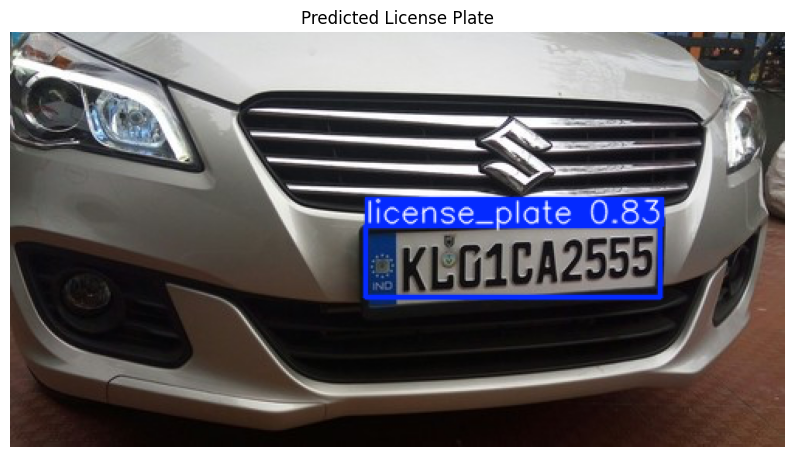

In [74]:
# VISUALISASI HASIL DETEKSI
result_img = results[0].plot()
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(result_img)
plt.title("Predicted License Plate")
plt.axis("off")
plt.show()

**Via Upload** 

In [78]:
# Widget uploader
uploader = widgets.FileUpload(
    accept='image/*',  
    multiple=False      
)
print("Upload gambar untuk di deteksi:")
display(uploader)

Upload gambar untuk di deteksi:


FileUpload(value=(), accept='image/*', description='Upload')

Berhasil upload: video-viral-mobil-berwarna-hitam-melintas-di-area-jogging-track-Alun-alun-M-Hasibuan.webp
Tersimpan di: /kaggle/working/video-viral-mobil-berwarna-hitam-melintas-di-area-jogging-track-Alun-alun-M-Hasibuan.webp
Dimensi: (675, 1200, 3)


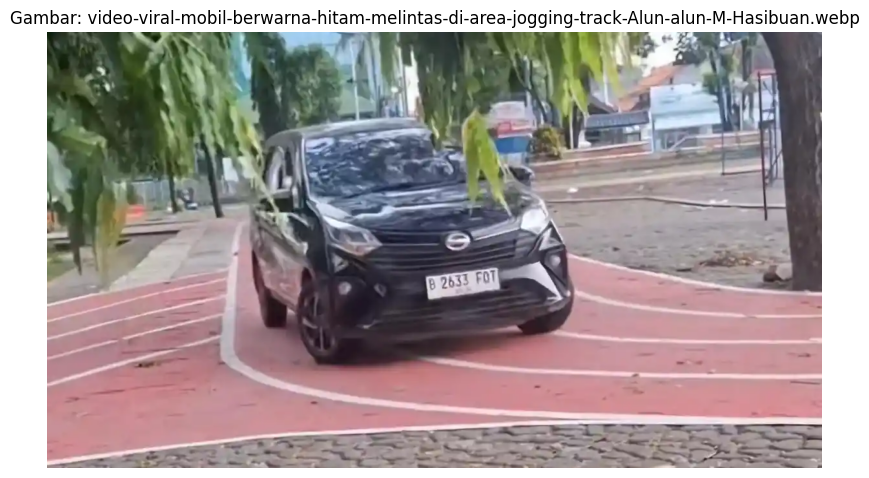

In [80]:
if len(uploader.value) > 0:
    uploaded_data = uploader.value[0]
    
    # Ekstrak informasi file
    filename = uploaded_data.get('name', 'unknown.jpg')
    file_content = uploaded_data.get('content', b'')
    file_bytes = np.frombuffer(file_content, np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    
    # Simpan ke folder working
    saved_path = f"/kaggle/working/{filename}"
    cv2.imwrite(saved_path, img)
    
    print(f"Berhasil upload: {filename}")
    print(f"Tersimpan di: {saved_path}")
    print(f"Dimensi: {img.shape}")
    
    # Tampilkan gambar
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Gambar: {filename}")
    plt.axis('off')
    plt.show()
else:
    print("Belum ada file yang diupload")

In [81]:
resultsUpload = model.predict(
    source=filename,
    imgsz=320,
    conf=0.25
)
print(resultsUpload)


image 1/1 /kaggle/working/video-viral-mobil-berwarna-hitam-melintas-di-area-jogging-track-Alun-alun-M-Hasibuan.webp: 192x320 1 license_plate, 37.3ms
Speed: 1.0ms preprocess, 37.3ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'license_plate'}
obb: None
orig_img: array([[[  7,  29,  10],
        [  7,  29,  10],
        [  7,  29,  10],
        ...,
        [139, 128, 128],
        [139, 128, 128],
        [139, 128, 128]],

       [[  7,  29,  10],
        [  7,  29,  10],
        [  7,  29,  10],
        ...,
        [137, 126, 125],
        [139, 128, 128],
        [139, 128, 128]],

       [[  8,  31,  11],
        [  8,  31,  11],
        [  8,  31,  11],
        ...,
        [129, 118, 117],
        [136, 125, 124],
        [137, 126, 125]],

       ...,

       [[135, 138, 156],
        [135, 138, 156],
        [13

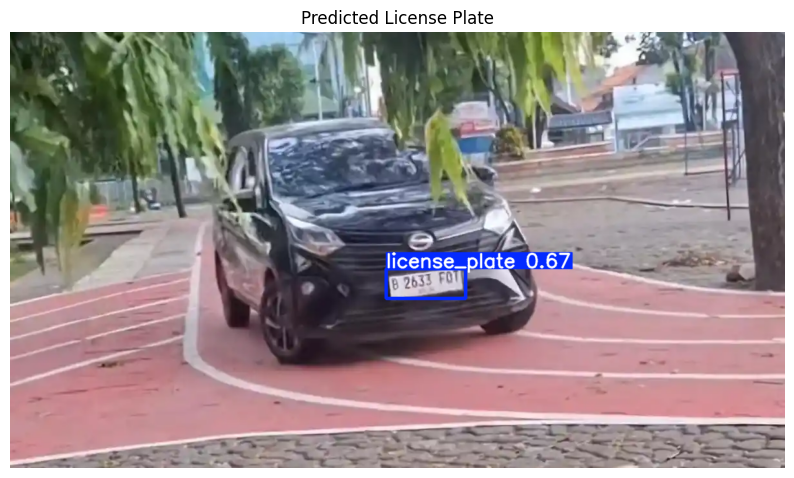

In [82]:
result_imgUpload = resultsUpload[0].plot()
result_imgUpload = cv2.cvtColor(result_imgUpload, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(result_imgUpload)
plt.title("Predicted License Plate")
plt.axis("off")
plt.show()